# CSEE Human vs LLM EDA

本 Notebook 用于分析 CSEE 外部验证集（Human + ERNIE 生成 LLM）的分布特征，并导出图表用于论文/答辩展示。

输出目录：`outputs/csee_eda_only/`


In [ ]:
# 如需安装依赖，取消注释
# !pip install -q pandas numpy matplotlib seaborn

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

In [2]:
ROOT = Path.cwd()
if not (ROOT / 'CESS').exists() and (ROOT.parent / 'CESS').exists():
    ROOT = ROOT.parent

DATA_MIXED = ROOT / 'CESS' / 'CSEE_human_llm_balanced.csv'
DATA_RAW = ROOT / 'CESS' / 'CSEE_data.csv'
OUT_DIR = ROOT / 'outputs' / 'csee_eda_only'
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_MIXED.exists(), f'missing file: {DATA_MIXED}'
print('ROOT:', ROOT)
print('MIXED:', DATA_MIXED)
print('RAW:', DATA_RAW if DATA_RAW.exists() else 'not found')
print('OUT_DIR:', OUT_DIR)

ROOT: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text
MIXED: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/CESS/CSEE_human_llm_balanced.csv
RAW: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/CESS/CSEE_data.csv
OUT_DIR: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/csee_eda_only


In [3]:
df = pd.read_csv(DATA_MIXED)
text_col = 'essay' if 'essay' in df.columns else 'text'
assert 'label' in df.columns, 'label column missing'

df[text_col] = df[text_col].fillna('').astype(str)
df = df[df[text_col].str.len() > 0].copy().reset_index(drop=True)
df['text_len'] = df[text_col].str.len()
df['word_len'] = df[text_col].str.split().map(len)
df['class_name'] = df['label'].map({0:'Human',1:'LLM'}).fillna('Unknown')

print('shape:', df.shape)
print(df['label'].value_counts().sort_index().to_dict())
df.head(3)

shape: (26488, 8)
{0: 13260, 1: 13228}


,essay_id,prompt_id,prompt,essay,label,text_len,word_len,class_name
0,11039714,1,"Suppose you are Li Hua, a senior student at Ho...","Dear Jim,\nI'm glad to write to you. Our schoo...",0,503,98,Human
1,11035775,1,"Suppose you are Li Hua, a senior student at Ho...","Dear Jim,\nI hope you are doing well in Britai...",0,728,135,Human
2,11034702,1,"Suppose you are Li Hua, a senior student at Ho...","Dear Jim,\nHow have you been lately? Graduatio...",0,738,139,Human


## 1. 数据构成统计（可直接做表格）

In [5]:
summary = (
    df['label']
    .value_counts()
    .sort_index()
    .rename(index={0: 'Human(0)', 1: 'LLM(1)'})
    .rename('count')
    .reset_index()
    .rename(columns={'index': 'class'})
)
summary['ratio'] = summary['count'] / summary['count'].sum()
summary.to_csv(OUT_DIR / 'table_csee_label_composition.csv', index=False)
print(summary)
print('saved:', OUT_DIR / 'table_csee_label_composition.csv')


      label  count     ratio
0  Human(0)  13260  0.500604
1    LLM(1)  13228  0.499396
saved: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/csee_eda_only/table_csee_label_composition.csv


## 2. 标签分布图

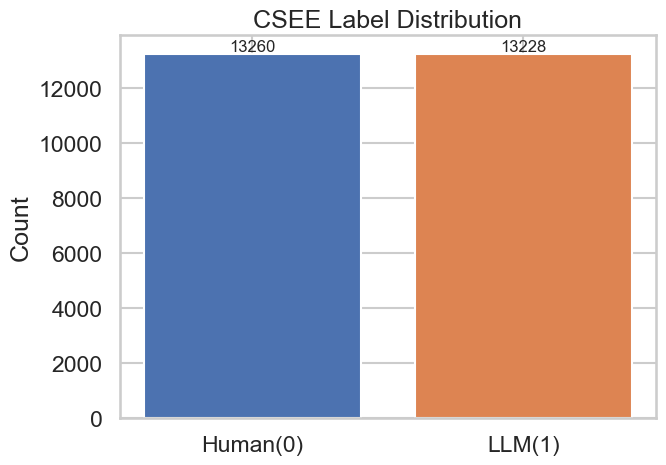

saved: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/csee_eda_only/fig_label_distribution.png


In [6]:
fig, ax = plt.subplots(figsize=(7,5))
counts = df['label'].value_counts().sort_index()
labels = ['Human(0)', 'LLM(1)']
vals = [int(counts.get(0,0)), int(counts.get(1,0))]
colors = ['#4C72B0', '#DD8452']
ax.bar(labels, vals, color=colors)
for i,v in enumerate(vals):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
ax.set_title('CSEE Label Distribution')
ax.set_ylabel('Count')
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig_label_distribution.png', dpi=240)
plt.show()
print('saved:', OUT_DIR / 'fig_label_distribution.png')

## 3. 文本长度分布（字符）

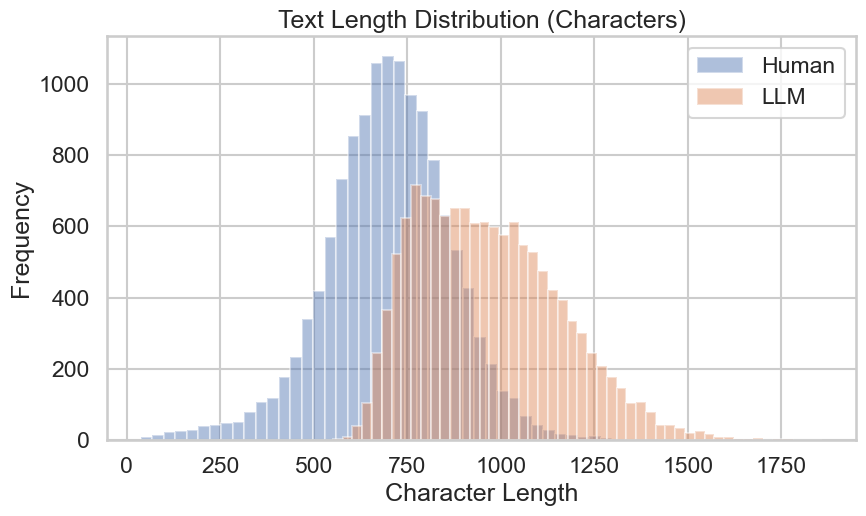

saved: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/csee_eda_only/fig_text_len_hist.png


In [7]:
fig, ax = plt.subplots(figsize=(9,5.5))
for lbl, name, color in [(0,'Human','#4C72B0'),(1,'LLM','#DD8452')]:
    vals = df.loc[df['label']==lbl, 'text_len'].values
    if len(vals) > 0:
        ax.hist(vals, bins=50, alpha=0.45, label=name, color=color)
ax.set_title('Text Length Distribution (Characters)')
ax.set_xlabel('Character Length')
ax.set_ylabel('Frequency')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig_text_len_hist.png', dpi=240)
plt.show()
print('saved:', OUT_DIR / 'fig_text_len_hist.png')

## 4. 文本长度分布（箱线图）

/var/folders/d7/pl_p_f4x5lb6768z5pnxfv5h0000gn/T/ipykernel_70745/3641623893.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class_name', y='text_len', ax=ax, palette=['#4C72B0','#DD8452'])


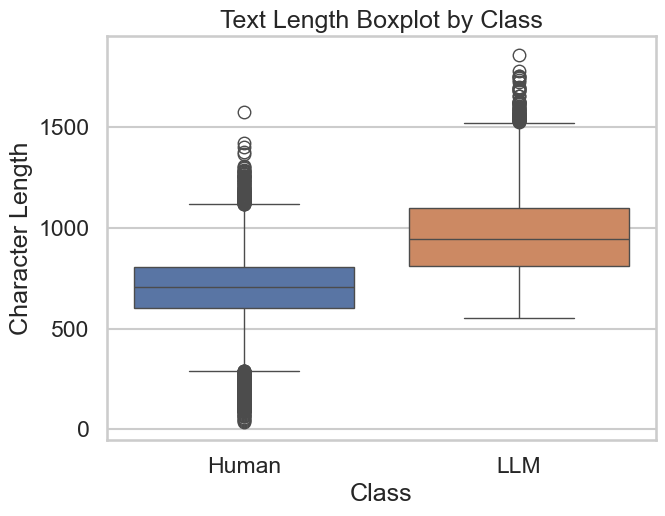

saved: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/csee_eda_only/fig_text_len_boxplot.png


In [8]:
fig, ax = plt.subplots(figsize=(7,5.5))
sns.boxplot(data=df, x='class_name', y='text_len', ax=ax, palette=['#4C72B0','#DD8452'])
ax.set_title('Text Length Boxplot by Class')
ax.set_xlabel('Class')
ax.set_ylabel('Character Length')
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig_text_len_boxplot.png', dpi=240)
plt.show()
print('saved:', OUT_DIR / 'fig_text_len_boxplot.png')

## 5. 词数分布

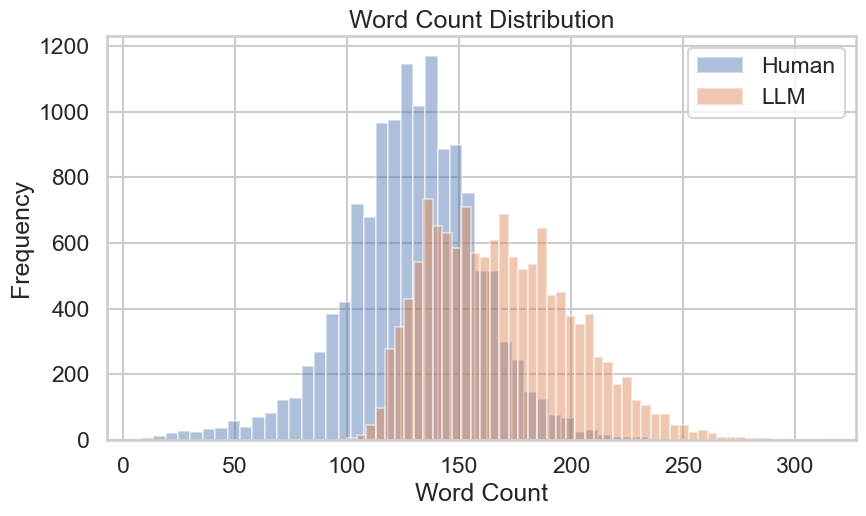

saved: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/csee_eda_only/fig_word_len_hist.png


In [9]:
fig, ax = plt.subplots(figsize=(9,5.5))
for lbl, name, color in [(0,'Human','#4C72B0'),(1,'LLM','#DD8452')]:
    vals = df.loc[df['label']==lbl, 'word_len'].values
    if len(vals) > 0:
        ax.hist(vals, bins=50, alpha=0.45, label=name, color=color)
ax.set_title('Word Count Distribution')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig_word_len_hist.png', dpi=240)
plt.show()
print('saved:', OUT_DIR / 'fig_word_len_hist.png')

## 6. Prompt 维度分布（如果有 prompt_id）

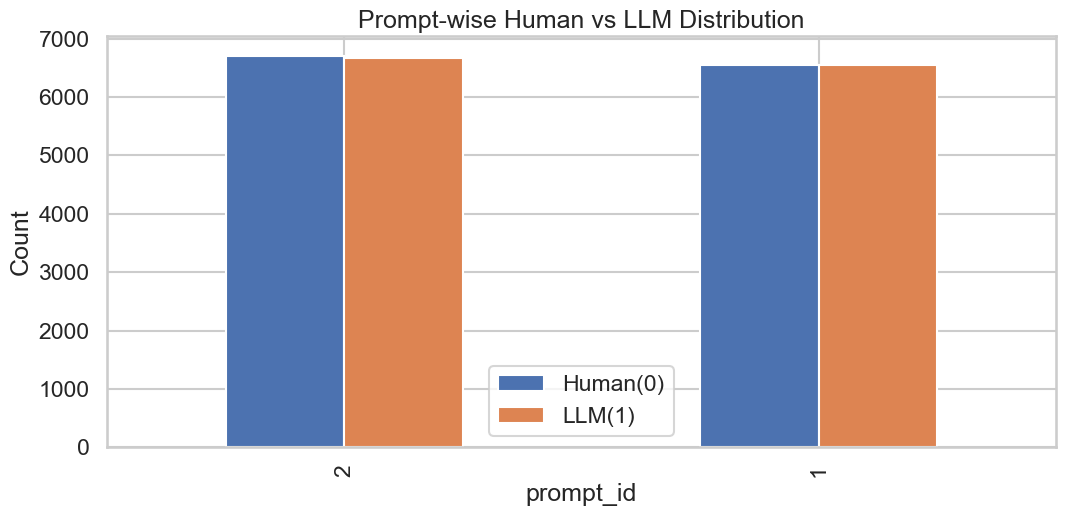

saved: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/csee_eda_only/table_prompt_label_distribution.csv
saved: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/csee_eda_only/fig_prompt_label_distribution.png


In [10]:
if 'prompt_id' in df.columns:
    prompt_stats = df.groupby(['prompt_id','label']).size().unstack(fill_value=0)
    prompt_stats.columns = ['Human(0)' if c==0 else 'LLM(1)' for c in prompt_stats.columns]
    prompt_stats['total'] = prompt_stats.sum(axis=1)
    prompt_stats = prompt_stats.sort_values('total', ascending=False)
    prompt_stats.to_csv(OUT_DIR / 'table_prompt_label_distribution.csv')

    ax = prompt_stats[['Human(0)','LLM(1)']].plot(kind='bar', figsize=(11,5.5), color=['#4C72B0','#DD8452'])
    ax.set_title('Prompt-wise Human vs LLM Distribution')
    ax.set_xlabel('prompt_id')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig_prompt_label_distribution.png', dpi=240)
    plt.show()

    print('saved:', OUT_DIR / 'table_prompt_label_distribution.csv')
    print('saved:', OUT_DIR / 'fig_prompt_label_distribution.png')
else:
    print('prompt_id not found; skip this section.')

## 7. 长度统计描述（可用于文中描述）

In [11]:
desc = (
    df.groupby('class_name')[['text_len','word_len']]
      .describe(percentiles=[0.25,0.5,0.75])
)
desc.to_csv(OUT_DIR / 'table_length_descriptive_stats.csv')
print(desc)
print('saved:', OUT_DIR / 'table_length_descriptive_stats.csv')

           text_len                                                       \
              count        mean         std    min    25%    50%     75%   
class_name                                                                 
Human       13260.0  701.055581  167.625094   38.0  601.0  704.5   808.0   
LLM         13228.0  967.018446  191.659782  551.0  812.0  947.0  1096.0   

                   word_len                                              \
               max    count        mean        std    min    25%    50%   
class_name                                                                
Human       1575.0  13260.0  129.429487  29.931192    8.0  112.0  130.0   
LLM         1859.0  13228.0  169.294980  32.017975  100.0  144.0  166.0   

                          
              75%    max  
class_name                
Human       148.0  284.0  
LLM         191.0  312.0  
saved: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Dete

## 8. 可选：与原始 Human 数据一致性检查

In [12]:
if DATA_RAW.exists():
    raw = pd.read_csv(DATA_RAW)
    raw_text_col = 'essay' if 'essay' in raw.columns else ('text' if 'text' in raw.columns else None)
    if raw_text_col:
        raw[raw_text_col] = raw[raw_text_col].fillna('').astype(str)
        raw = raw[raw[raw_text_col].str.len() > 0].copy()
        print('raw human rows:', len(raw))
        print('mixed human rows:', int((df['label']==0).sum()))
    else:
        print('raw file has no essay/text column')
else:
    print('raw file not found, skip')

raw human rows: 13270
mixed human rows: 13260
